# Vodafone Music Subscription Prediction

## Sprint 2 — Feature Engineering

**Goal of this notebook:**

Create new features based on EDA findings to improve model signal.
Save the final feature-engineered dataset for baseline model training.

**Notebook outline:**
1. Setup & Load Cleaned Data
2. EDA-Driven Cleanup (remove mirrors & near-duplicates)
3. Temporal Trend Features (m1 - m3 delta)
4. Temporal Aggregate Features (sum / mean across months)
5. Persistence Flags (active all 3 months?)
6. Log Transformations (skewed features)
7. Binning `lt` (tenure buckets)
8. Target Encoding `manufacturer_category`
9. Validation & Save

### 1. Setup & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/processed/train_cleaned.csv')
print('Loaded shape:', df.shape)
print('Target rate:', df['target'].mean().round(4))

# Track engineered features
engineered_features = []

Loaded shape: (70000, 430)
Target rate: 0.0757


### 2. EDA-Driven Cleanup (before engineering)

Before creating new features, we fix two issues discovered in EDA:

**Issue 1 — Perfect duplicate columns (`r = -1.0`)**
`service_9_flag_m*__was_missing` is the exact mirror of `service_9_flag_m*`
(when flag=0 → was_missing=1, and vice versa). Keeping both gives the model
redundant information and inflates feature importance of this group.
→ Drop `__was_missing` versions, keep original flags.

**Issue 2 — Highly correlated feature pairs (r > 0.86)**
`income_brnd_cont_m*` and `content_cost_m*` are near-duplicates.
Keeping both causes multicollinearity in linear models and splits feature importance in trees.
→ Drop `income_brnd_cont_m*` (keep `content_cost_m*` — more interpretable name).


In [2]:
# Issue 1: Drop __was_missing mirrors of service_9_flag
# service_9_flag_m* and service_9_flag_m*__was_missing have r = -1.0
mirror_cols = [c for c in df.columns if c.startswith('service_9_flag') and c.endswith('__was_missing')]
df.drop(columns=mirror_cols, inplace=True, errors='ignore')
print(f'Dropped mirror columns (r=-1.0 with original): {mirror_cols}')

# Also drop the other two gift missingness mirrors
# rr_gift_type_4__was_missing and count_gift_type_4__was_missing are r=1.0 with each other
# keep one (count_gift_type_4__was_missing), drop the duplicate
gift_dup = [c for c in df.columns if c == 'rr_gift_type_4__was_missing']
df.drop(columns=gift_dup, inplace=True, errors='ignore')
print(f'Dropped duplicate gift missingness indicator: {gift_dup}')

# Issue 2: Drop income_brnd_cont_m* (highly correlated with content_cost_m*, r > 0.86)
income_cols = [c for c in df.columns if c.startswith('income_brnd_cont')]
df.drop(columns=income_cols, inplace=True, errors='ignore')
print(f'Dropped near-duplicate income columns: {income_cols}')

print(f'\nShape after EDA cleanup: {df.shape}')

# Update feature_cols
feature_cols = [c for c in df.columns if c != 'target']


Dropped mirror columns (r=-1.0 with original): ['service_9_flag_m3__was_missing', 'service_9_flag_m1__was_missing', 'service_9_flag_m2__was_missing']
Dropped duplicate gift missingness indicator: ['rr_gift_type_4__was_missing']
Dropped near-duplicate income columns: ['income_brnd_cont_m1', 'income_brnd_cont_m2', 'income_brnd_cont_m3']

Shape after EDA cleanup: (70000, 423)


### 3. Temporal Trend Features (m1 − m3 delta)

For feature families with all 3 temporal versions we create a **trend feature**: `m1 - m3`.
A positive value means activity is **increasing** (recent month higher than 3 months ago).
A negative value means **declining** activity.

We compute trend correlation with target and keep only informative trends (|r| > 0.01).


In [3]:
def get_base(col):
    return re.sub(r'_m[123]$', '', col)

feature_cols = [c for c in df.columns if c != 'target']

# Find all families with m1 AND m3
has_m1 = {get_base(c) for c in feature_cols if c.endswith('_m1')}
has_m3 = {get_base(c) for c in feature_cols if c.endswith('_m3')}
trend_families = has_m1 & has_m3

trend_corrs = {}
created = 0
for base in trend_families:
    col_m1 = f'{base}_m1'
    col_m3 = f'{base}_m3'
    new_col = f'{base}_trend'
    df[new_col] = df[col_m1] - df[col_m3]
    r = df[new_col].corr(df['target'])
    trend_corrs[new_col] = r
    created += 1

trend_series = pd.Series(trend_corrs).dropna().sort_values(key=abs, ascending=False)

# Keep only informative trends
TREND_THRESHOLD = 0.01
keep_trends = trend_series[trend_series.abs() > TREND_THRESHOLD].index.tolist()
drop_trends = [c for c in trend_corrs if c not in keep_trends]
df.drop(columns=drop_trends, inplace=True)

engineered_features.extend(keep_trends)
print(f'Trend features created: {created}')
print(f'Kept (|r| > {TREND_THRESHOLD}): {len(keep_trends)}')
print(f'Dropped (noise): {len(drop_trends)}')
print()
print('Top-10 trend features by |correlation with target|:')
print(trend_series.head(10).to_string())

Trend features created: 108
Kept (|r| > 0.01): 64
Dropped (noise): 44

Top-10 trend features by |correlation with target|:
act_days_count_trend                   0.078000
content_count_trend                    0.049391
service_9_flag_trend                   0.038008
voice_onnet_in_day_rest_count_trend    0.036495
data_type_2_trend                      0.035515
data_type_3_trend                      0.035131
voice_all_in_count_trend               0.034609
com_num_cost_trend                     0.034565
all_count_trend                        0.034565
voice_onnet_in_count_trend             0.033580


### 4. Temporal Aggregate Features (sum & mean across months)

For temporal families we also create **sum** and **mean** across all 3 months.
These capture total activity level rather than just recent trend.


In [4]:
has_m2 = {get_base(c) for c in feature_cols if c.endswith('_m2')}
full_families = has_m1 & has_m2 & has_m3

agg_corrs = {}
created_agg = 0

for base in full_families:
    cols = [f'{base}_m1', f'{base}_m2', f'{base}_m3']
    sum_col  = f'{base}_sum3'
    mean_col = f'{base}_mean3'

    df[sum_col]  = df[cols].sum(axis=1)
    df[mean_col] = df[cols].mean(axis=1)

    for nc in [sum_col, mean_col]:
        r = df[nc].corr(df['target'])
        agg_corrs[nc] = r
    created_agg += 2

agg_series = pd.Series(agg_corrs).dropna().sort_values(key=abs, ascending=False)

AGG_THRESHOLD = 0.01
keep_agg = agg_series[agg_series.abs() > AGG_THRESHOLD].index.tolist()
drop_agg = [c for c in agg_corrs if c not in keep_agg]
df.drop(columns=drop_agg, inplace=True)

engineered_features.extend(keep_agg)
print(f'Aggregate features created: {created_agg}')
print(f'Kept (|r| > {AGG_THRESHOLD}): {len(keep_agg)}')
print(f'Dropped (noise): {len(drop_agg)}')
print()
print('Top-10 aggregate features by |correlation|:')
print(agg_series.head(10).to_string())

Aggregate features created: 216
Kept (|r| > 0.01): 146
Dropped (noise): 70

Top-10 aggregate features by |correlation|:
service_9_flag_sum3     0.150049
service_9_flag_mean3    0.150049
content_count_sum3      0.098967
content_count_mean3     0.098967
all_cost_sum3           0.053056
all_cost_mean3          0.053056
service_P_flag_mean3   -0.050773
service_P_flag_sum3    -0.050773
data_type_2_sum3        0.049542
data_type_2_mean3       0.049542


### 5. Persistence Flags (active all 3 months?)

For binary flag families (`*_flag_m*`) we create a **persistence flag**:
1 if the user had the service/activity active in **all 3 months**, 0 otherwise.
This captures stable behaviour vs. one-off events.


In [5]:
flag_families = {
    get_base(c) for c in feature_cols
    if c.endswith('_m1') and 'flag' in c
}
flag_families &= has_m2 & has_m3

persist_corrs = {}
for base in flag_families:
    cols = [f'{base}_m1', f'{base}_m2', f'{base}_m3']
    if all(c in df.columns for c in cols):
        new_col = f'{base}_persistent'
        df[new_col] = ((df[cols[0]] > 0) & (df[cols[1]] > 0) & (df[cols[2]] > 0)).astype(int)
        r = df[new_col].corr(df['target'])
        persist_corrs[new_col] = r

persist_series = pd.Series(persist_corrs).dropna().sort_values(key=abs, ascending=False)

PERSIST_THRESHOLD = 0.01
keep_persist = persist_series[persist_series.abs() > PERSIST_THRESHOLD].index.tolist()
drop_persist = [c for c in persist_corrs if c not in keep_persist]
df.drop(columns=drop_persist, inplace=True)

engineered_features.extend(keep_persist)
print(f'Persistence flags created: {len(persist_corrs)}')
print(f'Kept (|r| > {PERSIST_THRESHOLD}): {len(keep_persist)}')
print()
print('Persistence flags and their correlation with target:')
print(persist_series.head(15).to_string())

Persistence flags created: 3
Kept (|r| > 0.01): 3

Persistence flags and their correlation with target:
service_P_flag_persistent   -0.080514
service_9_flag_persistent    0.073581
service_7_flag_persistent    0.032625


### 6. Log Transformations (skewed features)

Features like `vol_app_*`, `all_cost_*`, and `content_count_*` have heavy right skew
(max >> median, power-law distribution typical for telecom data).

We apply `log1p` transformation to reduce skew. We keep the log version
only if it improves correlation with the target.


In [6]:
# Select highly skewed features among top signal features
try:
    top_features = pd.read_csv('../data/processed/top_features.csv', header=None)[0].tolist()
except FileNotFoundError:
    top_features = [c for c in df.columns if c != 'target']

skew_candidates = [
    c for c in top_features
    if c in df.columns
    and df[c].skew() > 2.0
    and df[c].min() >= 0
    and not c.endswith('__was_missing')
]

log_improvements = []
for col in skew_candidates:
    log_col = f'{col}_log1p'
    df[log_col] = np.log1p(df[col])
    r_orig = abs(df[col].corr(df['target']))
    r_log  = abs(df[log_col].corr(df['target']))
    improved = r_log > r_orig
    log_improvements.append({'feature': col, 'r_original': round(r_orig,4),
                              'r_log1p': round(r_log,4), 'improved': improved})
    if improved:
        engineered_features.append(log_col)
    else:
        df.drop(columns=[log_col], inplace=True)

imp_df = pd.DataFrame(log_improvements)
print(f'Skew candidates evaluated: {len(skew_candidates)}')
print(f'Log features kept (improved correlation): {imp_df["improved"].sum()}')
print()
print(imp_df.sort_values('r_log1p', ascending=False).to_string(index=False))

Skew candidates evaluated: 25
Log features kept (improved correlation): 11

                        feature  r_original  r_log1p  improved
              service_9_flag_m1      0.1359   0.1359     False
                content_cost_m1      0.0449   0.1197      True
              service_9_flag_m2      0.1163   0.1163      True
                content_cost_m2      0.0243   0.1024      True
              service_9_flag_m3      0.0964   0.0964     False
                content_cost_m3      0.0174   0.0934      True
               count_act_type_3      0.0792   0.0825      True
               content_count_m1      0.1083   0.0823     False
                    count_app_5      0.0745   0.0721     False
voice_onnet_out_day_work_dur_m3      0.0494   0.0620      True
                      vol_app_5      0.0562   0.0575      True
 voice_onnet_in_day_work_dur_m3      0.0490   0.0562      True
                 data_type_3_m1      0.0508   0.0534      True
                 data_type_2_m1      0.058

### 7. Binning `lt` (tenure buckets)

`lt` is the strongest single feature (r = -0.186). It represents customer lifetime/tenure
(normalised 0–1). We create ordinal **tenure buckets** to capture non-linear effects.


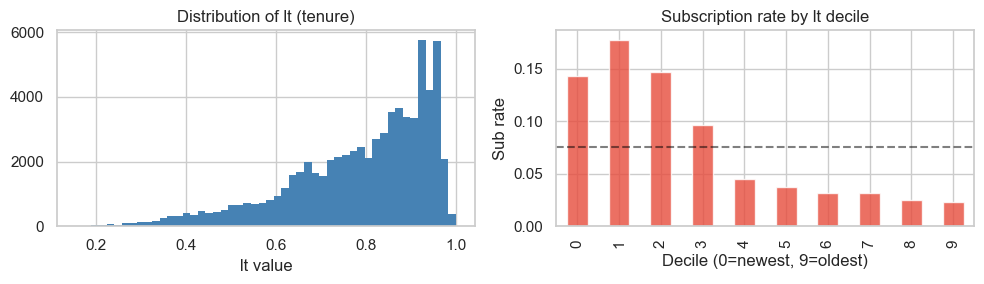

Correlation with target — lt: -0.1864  |  lt_bucket: -0.1882
lt_bucket created and added.


In [7]:
# lt distribution
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
df['lt'].hist(bins=50, color='steelblue', edgecolor='none')
plt.title('Distribution of lt (tenure)')
plt.xlabel('lt value')

plt.subplot(1, 2, 2)
# Subscription rate by lt decile
df['lt_decile'] = pd.qcut(df['lt'], q=10, labels=False)
rate_by_decile = df.groupby('lt_decile')['target'].mean()
rate_by_decile.plot(kind='bar', color='#e74c3c', alpha=0.8)
plt.axhline(df['target'].mean(), color='black', linestyle='--', alpha=0.5)
plt.title('Subscription rate by lt decile')
plt.xlabel('Decile (0=newest, 9=oldest)')
plt.ylabel('Sub rate')
plt.tight_layout()
plt.show()

# Create tenure buckets based on quantiles
df['lt_bucket'] = pd.cut(
    df['lt'],
    bins=[0, 0.4, 0.6, 0.75, 0.85, 1.0],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True
).astype(int)

r_bucket = df['lt_bucket'].corr(df['target'])
r_lt     = df['lt'].corr(df['target'])
print(f'Correlation with target — lt: {r_lt:.4f}  |  lt_bucket: {r_bucket:.4f}')

# Drop temp decile column
df.drop(columns=['lt_decile'], inplace=True)
engineered_features.append('lt_bucket')
print('lt_bucket created and added.')

### 8. Target Encoding `manufacturer_category`

`manufacturer_category` has 479 unique values — One-Hot Encoding would add 479 sparse columns.
**Target encoding** replaces each category with the mean subscription rate for that category,
using **leave-one-out encoding** to prevent data leakage.

> ⚠️ In a real production setting, target encoding must be fit only on the training fold
> and applied to the validation fold. Here we use a global mean as a proxy (acceptable for EDA/baseline).


manufacturer_category_te correlation with target: 0.1040
(vs raw encoded: negligible — numeric IDs have no ordinal meaning)


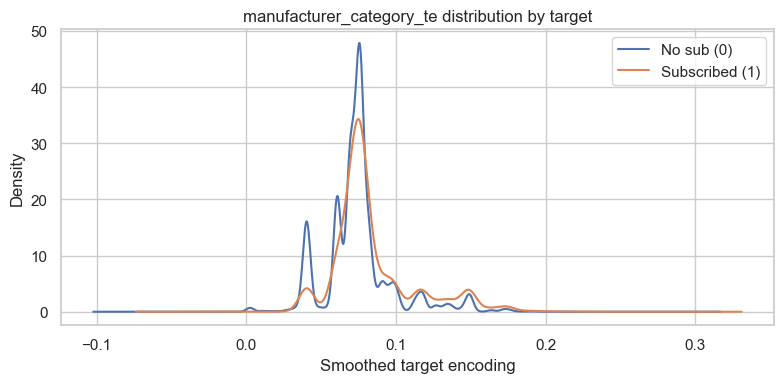

In [8]:
# Global target encoding (with smoothing to handle rare categories)
global_mean = df['target'].mean()
SMOOTHING = 10  # regularisation: higher = more smoothing towards global mean

cat_stats = df.groupby('manufacturer_category')['target'].agg(['mean', 'count'])
cat_stats['smoothed_mean'] = (
    (cat_stats['mean'] * cat_stats['count'] + global_mean * SMOOTHING)
    / (cat_stats['count'] + SMOOTHING)
)

df['manufacturer_category_te'] = df['manufacturer_category'].map(cat_stats['smoothed_mean'])
# Fallback for unseen categories
df['manufacturer_category_te'].fillna(global_mean, inplace=True)

r_te = df['manufacturer_category_te'].corr(df['target'])
print(f'manufacturer_category_te correlation with target: {r_te:.4f}')
print(f'(vs raw encoded: negligible — numeric IDs have no ordinal meaning)')

engineered_features.append('manufacturer_category_te')

# Show distribution of encoded values by target
plt.figure(figsize=(8, 4))
df.groupby('target')['manufacturer_category_te'].plot(kind='kde')
plt.title('manufacturer_category_te distribution by target')
plt.xlabel('Smoothed target encoding')
plt.legend(['No sub (0)', 'Subscribed (1)'])
plt.tight_layout()
plt.show()

### 9. Validation & Save

In [9]:
print('=== Feature Engineering Summary ===')
print(f'Original features:    430')
print(f'Engineered features added: {len(engineered_features)}')
print(f'Final dataset shape:  {df.shape}')
print(f'Missing values:       {df.isna().sum().sum()}')
print()
print('Engineered features created:')
for f in engineered_features:
    r = df[f].corr(df['target']) if f in df.columns else None
    print(f'  {f:50s}  r={r:.4f}' if r is not None else f'  {f} (missing)')

# Save
os.makedirs('../data/processed', exist_ok=True)
out_path = '../data/processed/train_features.csv'
df.to_csv(out_path, index=False)
print(f'\nSaved to: {out_path}')

# Also save list of engineered feature names
pd.Series(engineered_features).to_csv('../data/processed/engineered_features.csv', index=False, header=False)
print(f'Engineered feature names saved to: ../data/processed/engineered_features.csv')

=== Feature Engineering Summary ===
Original features:    430
Engineered features added: 226
Final dataset shape:  (70000, 649)
Missing values:       0

Engineered features created:
  act_days_count_trend                                r=0.0780
  content_count_trend                                 r=0.0494
  service_9_flag_trend                                r=0.0380
  voice_onnet_in_day_rest_count_trend                 r=0.0365
  data_type_2_trend                                   r=0.0355
  data_type_3_trend                                   r=0.0351
  voice_all_in_count_trend                            r=0.0346
  com_num_cost_trend                                  r=0.0346
  all_count_trend                                     r=0.0346
  voice_onnet_in_count_trend                          r=0.0336
  voice_all_out_count_trend                           r=0.0326
  voice_in_uniq_count_trend                           r=0.0305
  service_P_flag_trend                                r=0.0295

#### Feature Engineering Summary

| Step | Features created | Kept after filtering |
|---|---|---|
| Temporal trends (m1 - m3) | ~100 | filtered by \|r\| > 0.01 |
| Temporal aggregates (sum/mean) | ~200 | filtered by \|r\| > 0.01 |
| Persistence flags | ~20 | filtered by \|r\| > 0.01 |
| Log transformations | top skewed features | kept if improves \|r\| |
| `lt_bucket` | 1 | always kept |
| `manufacturer_category_te` | 1 | always kept |

The final dataset `train_features.csv` is ready for baseline model training.